<a href="https://colab.research.google.com/github/rtajeong/M3_2026/blob/main/lab56_topic_modeling_rev14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSA (Latent Semantic Analysis)
- LDA (토픽 모델링) 에 아이디어 제공한 알고리즘
- DTM(document-term matrix) 나 TfIdf matrix 에 Truncated SVD 이용

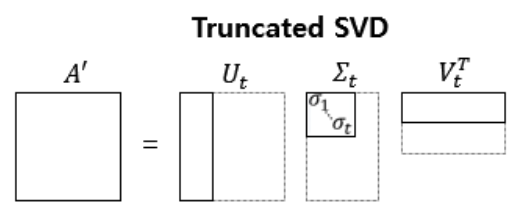

- example from https://wikidocs.net/24949

## LSA exercise

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

doc1 = "사과 먹고 싶다"
doc2 = "바나나 먹고 싶다"
doc3 = "길고 노란 바나나 바나나"
doc4 = "저는 과일이 좋아요"
corpus = np.array([doc1, doc2, doc3, doc4])
vec = CountVectorizer()
A = vec.fit_transform(corpus).toarray()
A

array([[0, 0, 0, 1, 0, 1, 1, 0, 0],
       [0, 0, 0, 1, 1, 0, 1, 0, 0],
       [0, 1, 1, 0, 2, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 1, 1]])

In [2]:
vec.get_feature_names_out()

array(['과일이', '길고', '노란', '먹고', '바나나', '사과', '싶다', '저는', '좋아요'],
      dtype=object)

In [3]:
A.shape

(4, 9)

In [4]:
U, s, VT = np.linalg.svd(A, full_matrices = True)
print('matrix U :')
print(U.round(2))

matrix U :
[[-0.24  0.75  0.   -0.62]
 [-0.51  0.44 -0.    0.74]
 [-0.83 -0.49 -0.   -0.27]
 [-0.   -0.    1.    0.  ]]


In [5]:
print('singular vectors :')
print(s.round(2))

singular vectors :
[2.69 2.05 1.73 0.77]


In [6]:
S = np.zeros((4,9))
S[:4, :4] = np.diag(s)
print(S.round(2))

[[2.69 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   2.05 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.73 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.77 0.   0.   0.   0.   0.  ]]


In [7]:
print('matrix VT :')
print(VT.round(2))

matrix VT :
[[-0.   -0.31 -0.31 -0.28 -0.8  -0.09 -0.28 -0.   -0.  ]
 [ 0.   -0.24 -0.24  0.58 -0.26  0.37  0.58 -0.   -0.  ]
 [ 0.58 -0.    0.    0.   -0.    0.   -0.    0.58  0.58]
 [ 0.   -0.35 -0.35  0.16  0.25 -0.8   0.16 -0.   -0.  ]
 [-0.   -0.78 -0.01 -0.2   0.4   0.4  -0.2   0.    0.  ]
 [-0.29  0.31 -0.78 -0.24  0.23  0.23  0.01  0.14  0.14]
 [-0.29 -0.1   0.26 -0.59 -0.08 -0.08  0.66  0.14  0.14]
 [-0.5  -0.06  0.15  0.24 -0.05 -0.05 -0.19  0.75 -0.25]
 [-0.5  -0.06  0.15  0.24 -0.05 -0.05 -0.19 -0.25  0.75]]


In [8]:
np.allclose(A, np.dot(np.dot(U,S), VT).round(2))

True

In [9]:
# let's take the top 2 signular values. -> 2 topics
S = S[:2, :2]; S.round(2)

array([[2.69, 0.  ],
       [0.  , 2.05]])

In [10]:
U = U[:, :2]; U.round(2)   # (4,2) -> 문서의 수 x 토픽의 수
                           # U의 각 행은 잠재 의미를 표현하기 위한 수치화 된 각각의 문서 벡터

array([[-0.24,  0.75],
       [-0.51,  0.44],
       [-0.83, -0.49],
       [-0.  , -0.  ]])

In [11]:
VT = VT[:2, :]; VT.round(2)   # (2,9) -> 토픽의 수 x 단어의 갯수
                              # VT 의 각 열은 잠재 의미를 표현하기 위해 수치화된 각각의 단어 벡터

array([[-0.  , -0.31, -0.31, -0.28, -0.8 , -0.09, -0.28, -0.  , -0.  ],
       [ 0.  , -0.24, -0.24,  0.58, -0.26,  0.37,  0.58, -0.  , -0.  ]])

In [12]:
A_prime = U @ S @ VT; A_prime.round(2)

array([[ 0.  , -0.17, -0.17,  1.08,  0.12,  0.62,  1.08, -0.  , -0.  ],
       [ 0.  ,  0.2 ,  0.2 ,  0.91,  0.86,  0.45,  0.91,  0.  ,  0.  ],
       [ 0.  ,  0.93,  0.93,  0.03,  2.05, -0.17,  0.03,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.  ,  0.  ]])

- it is a little different from the original matrix because of the truncation.

- Let's use the library function

In [13]:
svd_model = TruncatedSVD(n_components=2, random_state=122)
svd_model.fit(A)
svd_model.components_.round(2)      # VT matrix

array([[-0.  ,  0.31,  0.31,  0.28,  0.8 ,  0.09,  0.28, -0.  , -0.  ],
       [-0.  , -0.24, -0.24,  0.58, -0.26,  0.37,  0.58, -0.  , -0.  ]])

In [14]:
svd_model.singular_values_

array([2.68731789, 2.04508425])

## LSA (sklearn) with newsgroup data
  - Twenty Newsgroups이라고 불리는 20개의 다른 주제를 가진 뉴스그룹 데이터 (sklearn)
  - 문서의 수를 원하는 토픽의 수로 압축한 뒤에 각 토픽당 가장 중요한 단어 5개를 출력하는 실습으로 토픽 모델링을 수행

In [15]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

In [16]:
dataset = fetch_20newsgroups(shuffle=True, random_state=1, remove=('headers', 'footers', 'quotes'))
documents = dataset.data
print('샘플의 수 :',len(documents))

샘플의 수 : 11314


In [17]:
# dir(dataset)

In [18]:
dataset.target

array([17,  0, 17, ...,  9,  4,  9])

In [19]:
dataset.target_names      #  20개의 뉴스그룹 카테고리

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [20]:
documents[0]

"Well i'm not sure about the story nad it did seem biased. What\nI disagree with is your statement that the U.S. Media is out to\nruin Israels reputation. That is rediculous. The U.S. media is\nthe most pro-israeli media in the world. Having lived in Europe\nI realize that incidences such as the one described in the\nletter have occured. The U.S. media as a whole seem to try to\nignore them. The U.S. is subsidizing Israels existance and the\nEuropeans are not (at least not to the same degree). So I think\nthat might be a reason they report more clearly on the\natrocities.\n\tWhat is a shame is that in Austria, daily reports of\nthe inhuman acts commited by Israeli soldiers and the blessing\nreceived from the Government makes some of the Holocaust guilt\ngo away. After all, look how the Jews are treating other races\nwhen they got power. It is unfortunate.\n"

In [21]:
pd.DataFrame({'document':documents})

,document
0,Well i'm not sure about the story nad it did s...
1,"\n\n\n\n\n\n\nYeah, do you expect people to re..."
2,Although I realize that principle is not one o...
3,Notwithstanding all the legitimate fuss about ...
4,"Well, I will have to change the scoring on my ..."
...,...
11309,"Danny Rubenstein, an Israeli journalist, will ..."
11310,\n
11311,\nI agree. Home runs off Clemens are always m...
11312,I used HP DeskJet with Orange Micros Grappler ...


In [22]:
# text preprocessing
news_df = pd.DataFrame({'document':documents})
# 특수 문자 제거
news_df['clean_doc'] = news_df['document'].str.replace("[^a-zA-Z]", " ")
# 길이가 3이하인 단어는 제거 (길이가 짧은 단어 제거)
news_df['clean_doc'] = news_df['clean_doc'].apply(lambda x: ' '.join([w for w in x.split() if len(w)>3]))
# 전체 단어에 대한 소문자 변환
news_df['clean_doc'] = news_df['clean_doc'].apply(lambda x: x.lower())

In [23]:
news_df['clean_doc'][0]

'well sure about story seem biased. what disagree with your statement that u.s. media ruin israels reputation. that rediculous. u.s. media most pro-israeli media world. having lived europe realize that incidences such described letter have occured. u.s. media whole seem ignore them. u.s. subsidizing israels existance europeans least same degree). think that might reason they report more clearly atrocities. what shame that austria, daily reports inhuman acts commited israeli soldiers blessing received from government makes some holocaust guilt away. after all, look jews treating other races when they power. unfortunate.'

In [24]:
# NLTK로부터 불용어를 받아와 제거한다.
nltk.download('stopwords')
stop_words = stopwords.words('english')
tokenized_doc = news_df['clean_doc'].apply(lambda x: x.split())   # split default - any whitespace
tokenized_doc = tokenized_doc.apply(lambda x: [item for item in x if item not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
print(tokenized_doc[:2])

0    [well, sure, story, seem, biased., disagree, s...
1    [yeah,, expect, people, read, faq,, etc., actu...
Name: clean_doc, dtype: object


In [26]:
# tf-idf matrix
detokenized_doc = []
for i in range(len(news_df)):
    t = ' '.join(tokenized_doc[i])
    detokenized_doc.append(t)

news_df['clean_doc'] = detokenized_doc

In [27]:
news_df['clean_doc'][0]

'well sure story seem biased. disagree statement u.s. media ruin israels reputation. rediculous. u.s. media pro-israeli media world. lived europe realize incidences described letter occured. u.s. media whole seem ignore them. u.s. subsidizing israels existance europeans least degree). think might reason report clearly atrocities. shame austria, daily reports inhuman acts commited israeli soldiers blessing received government makes holocaust guilt away. all, look jews treating races power. unfortunate.'

In [28]:
vectorizer = TfidfVectorizer(stop_words='english',
                             max_features= 1000, # 상위 1,000개의 단어
                             max_df = 0.5,       # ignore terms of df higher than 0.5
                             smooth_idf=True)

X = vectorizer.fit_transform(news_df['clean_doc'])

print(X.shape)

(11314, 1000)


In [29]:
# topic modeling
svd_model = TruncatedSVD(n_components=20,
                         n_iter=100,
                         random_state=122)
svd_model.fit(X)

document_topic_matrix = svd_model.transform(X)   # U matrix
topic_word_matrix = svd_model.components_        # VT matrix

print(document_topic_matrix.shape, topic_word_matrix.shape)

(11314, 20) (20, 1000)


In [30]:
svd_model.singular_values_  # singular values do not have any meaning.

array([16.90871344, 10.00598331,  8.21936031,  7.98269175,  7.70075419,
        7.58424343,  7.24908661,  7.17123904,  6.90917796,  6.86585132,
        6.76982639,  6.67631039,  6.58982357,  6.49789562,  6.42711266,
        6.32897935,  6.22690358,  6.21905139,  6.09497502,  6.00365555])

- 각 20개의 topic에 대해 각 1,000개의 열 (words) 중 가장 값이 큰 5개의 값을 찾아서 단어로 출력.

In [31]:
# first row 에 대해 먼저 확인
idx_5 = svd_model.components_[0].argsort()[-5:]
idx_5

array([405, 895, 654, 488, 514])

In [32]:
[vectorizer.get_feature_names_out()[i] for i in idx_5][::-1]

['like', 'know', 'people', 'think', 'good']

In [33]:
# 모든 row 에 대해 확인
terms = vectorizer.get_feature_names_out()       # 단어 집합. 1,000개의 단어가 저장됨.

def get_topics(components, feature_names, n=5):
    for idx, topic in enumerate(components, 1):
        # print("Topic %d:" % (idx), [(feature_names[i], topic[i].round(5)) for i in topic.argsort()[:-n - 1:-1]])
        print("Topic %d:" % (idx), [(feature_names[i], topic[i].round(5)) for i in topic.argsort()[-n:][::-1]])

get_topics(svd_model.components_, terms)

Topic 1: [('like', np.float64(0.21065)), ('know', np.float64(0.19865)), ('people', np.float64(0.19337)), ('think', np.float64(0.17695)), ('good', np.float64(0.15024))]
Topic 2: [('thanks', np.float64(0.31432)), ('windows', np.float64(0.27918)), ('card', np.float64(0.17317)), ('drive', np.float64(0.16121)), ('mail', np.float64(0.14636))]
Topic 3: [('game', np.float64(0.36793)), ('team', np.float64(0.31524)), ('year', np.float64(0.28778)), ('games', np.float64(0.23177)), ('season', np.float64(0.17117))]
Topic 4: [('edu', np.float64(0.49691)), ('thanks', np.float64(0.25806)), ('mail', np.float64(0.17646)), ('com', np.float64(0.11305)), ('email', np.float64(0.11137))]
Topic 5: [('edu', np.float64(0.51015)), ('drive', np.float64(0.24504)), ('com', np.float64(0.1097)), ('sale', np.float64(0.10501)), ('soon', np.float64(0.09464))]
Topic 6: [('drive', np.float64(0.40158)), ('thanks', np.float64(0.34907)), ('know', np.float64(0.28252)), ('scsi', np.float64(0.13753)), ('mail', np.float64(0.11316

- Pros and Cons of LSA:
  - can be implemented easily and quickly.
  - good performance in calculating the similarity of documents as it can derive the potential meaning of word
  - But, if you add new data, you should recalculate it (difficult to update)
  - that is why word embedding (like Word2Vec) is in the spotlight.

# LDA in sklearn

In [34]:
lda = LatentDirichletAllocation(n_components=20,
                                learning_method="batch",
                                max_iter=100,
                                random_state=0)

lda.fit(X)

document_topic_matrix = lda.transform(X)  # document-topic distribution
topic_word_matrix = lda.components_       # topic-term distribution

print(document_topic_matrix.shape, topic_word_matrix.shape)

(11314, 20) (20, 1000)


In [35]:
lda.components_[0].argsort()[-5:]

array([ 69, 325, 219, 541, 891])

In [36]:
lda.get_params()   # doc_topic_prior = alpha, topic_word_prior = beta
                   # both are by default 1/n_components

{'batch_size': 128,
 'doc_topic_prior': None,
 'evaluate_every': -1,
 'learning_decay': 0.7,
 'learning_method': 'batch',
 'learning_offset': 10.0,
 'max_doc_update_iter': 100,
 'max_iter': 100,
 'mean_change_tol': 0.001,
 'n_components': 20,
 'n_jobs': None,
 'perp_tol': 0.1,
 'random_state': 0,
 'topic_word_prior': None,
 'total_samples': 1000000.0,
 'verbose': 0}

In [37]:
# 모든 row 에 대해 확인
get_topics(topic_word_matrix, terms)  # weights of the words (not normalized)

Topic 1: [('thanks', np.float64(75.69841)), ('mail', np.float64(61.62377)), ('com', np.float64(39.48449)), ('email', np.float64(37.62687)), ('address', np.float64(37.24144))]
Topic 2: [('israel', np.float64(55.53628)), ('israeli', np.float64(37.20356)), ('jews', np.float64(34.61991)), ('jewish', np.float64(29.52117)), ('arab', np.float64(22.98782))]
Topic 3: [('game', np.float64(91.04487)), ('team', np.float64(82.35589)), ('year', np.float64(73.8464)), ('games', np.float64(57.60053)), ('season', np.float64(50.56377))]
Topic 4: [('ground', np.float64(17.45798)), ('steve', np.float64(16.1337)), ('right', np.float64(15.28165)), ('road', np.float64(14.12756)), ('like', np.float64(13.16867))]
Topic 5: [('heard', np.float64(24.32218)), ('answer', np.float64(23.45181)), ('test', np.float64(14.5236)), ('wrong', np.float64(13.99687)), ('question', np.float64(12.60743))]
Topic 6: [('windows', np.float64(86.23189)), ('file', np.float64(81.68926)), ('window', np.float64(67.93843)), ('files', np.fl

- try to compare the results with the target

In [38]:
dataset.target_names      #  20개의 뉴스그룹 카테고리

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

- in LSA(TruncatedSVD)
  - components_: topic-term distribution
  - transform(): provides the document-topic distribution
- in LDA
  - components_: Represents the topic-term distribution (similar to the right singular vectors in SVD).
  - transform(): Provides the document-topic distribution (similar to the left singular vectors in SVD).

# Two libraries for LDA



- sklearn:
  - 주요 초점: 범용 머신러닝 라이브러리다. LDA 구현은 광범위한 머신러닝 알고리즘 스위트의 일부이며, 일반적인 데이터 분석 작업을 위해 설계되었다.
  - 사용 편의성: 다른 머신러닝 작업에 Scikit-learn을 이미 사용하고 있다면, LDA를 사용하기에 편리하고 기존 워크플로우와 일관성이 있다.
  - 다른 ML 알고리즘과의 통합: LDA와 다른 머신러닝 기술을 쉽게 통합할 수 있으며, 다양한 알고리즘에 대해 일관된 API를 제공한다.
- gensim:
  - 주요 초점: 자연어 처리(NLP)와 **토픽 모델링(Topic Modeling)**에 특화되어 설계되었다. 대규모 텍스트 코퍼스(text corpora) 처리에 매우 적합하다.
  - 점진적 훈련: LDA 모델의 **점진적 훈련(Incremental Training)**을 지원한다. 이는 전체 데이터셋을 재처리할 필요 없이 모델을 실시간으로 업데이트하는 데 유용하다.
  - 효율성: 메모리 효율성과 **확장성(Scalability)**이 뛰어나다. 매우 큰 텍스트 코퍼스를 효율적으로 처리할 수 있다.
  - 맞춤 설정: LDA 매개변수 사용자 지정 및 모델 미세 조정(fine-tuning)에 더 많은 유연성을 제공한다.

# LDA in gensim
- LDA는 문서들은 토픽들의 혼합으로 구성되어져 있으며, 토픽들은 확률 분포에 기반하여 단어들을 생성한다고 가정.
- 데이터가 주어지면, LDA는 문서가 생성되던 과정을 역추적
- https://wikidocs.net/30708

- LDA algorithm:
  - (1) hyperparameter k is given
  - (2) assign all words to one of k topics
  - (3) iterate followings:
     - assume the word w is mis-assigned and all others are well- assigned
     - re-assign w based on:
        - p(topic t | document d) : 문서 d의 단어들 중 토픽 t에 해당하는 단어들의 비율
        - p(word w | topic t) : 각 토픽들 t에서 해당 단어 w의 분포

In [68]:
# let's use the same dataset as we used in LSA
print(tokenized_doc.shape)
tokenized_doc[:5]

(11314,)


,clean_doc
0,"[well, sure, story, seem, biased., disagree, s..."
1,"[yeah,, expect, people, read, faq,, etc., actu..."
2,"[although, realize, principle, strongest, poin..."
3,"[notwithstanding, legitimate, fuss, proposal,,..."
4,"[well,, change, scoring, playoff, pool., unfor..."


- record word frequency (word_id, word_freq)

In [67]:
import warnings
# 모든 DeprecationWarning 유형의 경고 메시지를 화면에 출력하지 않도록 설정
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [40]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.4 MB/s eta 0:00:00


In [69]:
from gensim import corpora

dictionary = corpora.Dictionary(tokenized_doc)
corpus = [dictionary.doc2bow(text) for text in tokenized_doc]
print(corpus[:2])

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 2), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 4), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 2), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 4), (55, 1), (56, 1), (57, 1), (58, 1)], [(59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 2), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1), (89, 2), (90, 1), (91, 1), (92, 1), (93, 1), (94, 1), (95, 1), (96, 2), (97, 1), (98, 1), (99, 1), (100, 1), (101, 1), (102, 1)]]


In [ ]:
# LDA train
import gensim

NUM_TOPICS = 20      # 20개의 토픽, k=20
# train the model
ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                           num_topics = NUM_TOPICS,
                                           id2word=dictionary,
                                           passes=15)   # The model is trained during the instantiation.


### 토픽별 단어의 분포

In [ ]:
topics = ldamodel.print_topics(num_words=5)  # 5 개의 단어만 출력
for topic in topics:
    print(topic)

- 20개의 토픽에 대해 각각 상위 5개의 단어 확률 분포
  - print_topics(num_words=5): 단순 확인용, 토픽 모델링 결과를 콘솔이나 노트북 셀에서 빠르게 확인하고 싶을 때.
  - show_topics(): 데이터 보관 및 시각화용, 출력된 토픽-단어 분포 문자열을 변수에 담아 후속 텍스트 처리나 시각화 모듈(pyLDAvis 등)에 넘겨주거나, 포매팅되지 않은 원시 튜플 구조(formatted=False)로 데이터를 정밀 제어하고 싶을 때.

In [71]:
# see the topics as a list of words
# - no natural ordering between the topics in LDA.

ldamodel.show_topics(num_topics=20, num_words=5, log=False, formatted=True)   # 5 개 단어 출력

[(0,
  '0.040*"space" + 0.013*"nasa" + 0.012*"launch" + 0.009*"satellite" + 0.008*"lunar"'),
 (1,
  '0.012*"jpeg" + 0.004*"visualization" + 0.004*"copies)" + 0.003*"annual" + 0.003*"francis"'),
 (2,
  '0.020*"team" + 0.018*"game" + 0.013*"games" + 0.011*"hockey" + 0.010*"players"'),
 (3,
  '0.006*"sumgait" + 0.005*"mamma" + 0.004*"unto" + 0.003*"apartment." + 0.003*"apartment"'),
 (4,
  '0.012*"chip" + 0.012*"encryption" + 0.008*"security" + 0.008*"keys" + 0.007*"government"'),
 (5,
  '0.011*"would" + 0.009*"people" + 0.007*"think" + 0.006*"like" + 0.005*"even"'),
 (6,
  '0.015*"55.0" + 0.009*"water" + 0.006*"games," + 0.003*"cooling" + 0.003*"plants"'),
 (7,
  '0.008*"surrender" + 0.008*"gordon" + 0.007*"----------------------------------------------------------------------------" + 0.007*"banks" + 0.006*"intellect,"'),
 (8,
  '0.006*"cancer" + 0.004*"patients" + 0.003*"patient" + 0.003*"diet" + 0.002*"suck"'),
 (9,
  '0.032*"-----------------------------------------------------------

### visualize LDA

In [ ]:
!pip install pyLDAvis

In [72]:
import pyLDAvis
import pyLDAvis.gensim_models  # Only needed if using gensim LDA

pyLDAvis.enable_notebook()     # to enable the display in notebooks
vis = pyLDAvis.gensim_models.prepare(ldamodel, corpus, dictionary)
pyLDAvis.display(vis)

### 문서 별 토픽 분포 보기

- ldamodel.get_document_topics() 사용

In [75]:
# 예: 0번째 문서의 토픽 분포 가져오기
doc_idx = 0
doc_topics = ldamodel.get_document_topics(corpus[doc_idx])

print(f"[{doc_idx}번째 문서의 토픽 분포]:")
print(doc_topics)

[0번째 문서의 토픽 분포]:
[(4, np.float32(0.019249327)), (5, np.float32(0.69938487)), (9, np.float32(0.07806221)), (18, np.float32(0.09709649)), (19, np.float32(0.09444968))]


In [83]:
import pandas as pd

# 1. 전체 문서에 대한 토픽 분포 리스트 생성 (모든 토픽 확률을 누락 없이 받기 위해 minimum_probability=0 설정)
all_doc_topics = ldamodel.get_document_topics(corpus, minimum_probability=0)

# 2. 각 문서별 토픽 확률값만 쏙 빼내어 2차원 리스트로 변환
matrix_data = []
for doc in all_doc_topics:
    # doc는 [(0, 0.01), (1, 0.85), ...] 구조이므로 확률값(p)만 추출
    matrix_data.append([p for topic_id, p in doc])

# 3. 데이터프레임 변환 (컬럼명을 Topic 0, Topic 1... 형식으로 지정)
num_topics = ldamodel.num_topics
df_doc_topic = pd.DataFrame(matrix_data, columns=[f"Topic {i}" for i in range(num_topics)])

# 4. 결과 확인
print("전체 문서별 토픽 분포 행렬:")
print(df_doc_topic.head())

전체 문서별 토픽 분포 행렬:
    Topic 0   Topic 1   Topic 2   Topic 3   Topic 4   Topic 5   Topic 6  \
0  0.000784  0.000784  0.000784  0.000784  0.019247  0.699456  0.000784   
1  0.001195  0.001195  0.001195  0.001195  0.001195  0.638523  0.001195   
2  0.000849  0.000849  0.000849  0.000849  0.038300  0.946416  0.000849   
3  0.000727  0.000727  0.000727  0.072280  0.369970  0.312561  0.000727   
4  0.001857  0.001857  0.171473  0.336387  0.037802  0.224063  0.001857   

    Topic 7   Topic 8   Topic 9  Topic 10  Topic 11  Topic 12  Topic 13  \
0  0.000784  0.000784  0.078062  0.000784  0.000784  0.000784  0.000784   
1  0.059008  0.001195  0.001195  0.001195  0.001195  0.001195  0.001195   
2  0.000849  0.000849  0.000849  0.000849  0.000849  0.000849  0.000849   
3  0.000727  0.000727  0.000727  0.000727  0.000727  0.000727  0.000727   
4  0.001857  0.001857  0.001857  0.001857  0.001857  0.001857  0.001857   

   Topic 14  Topic 15  Topic 16  Topic 17  Topic 18  Topic 19  
0  0.000784  0.00

- 각 문서별 모델 결과 확인

In [76]:
len(ldamodel[corpus])   # documents 수

11314

In [77]:
ldamodel[corpus][0]   # 0 번 document

[(4, np.float32(0.01924759)),
 (5, np.float32(0.69944954)),
 (9, np.float32(0.07806224)),
 (18, np.float32(0.09703352)),
 (19, np.float32(0.09444972))]

In [78]:
for i, topic_list in enumerate(ldamodel[corpus]):
    if i==10:
        break
    print(i,'번째 문서의 topic 비율은',topic_list)

0 번째 문서의 topic 비율은 [(4, np.float32(0.019247897)), (5, np.float32(0.6994379)), (9, np.float32(0.07806223)), (18, np.float32(0.0970448)), (19, np.float32(0.09444971))]
1 번째 문서의 topic 비율은 [(5, np.float32(0.63845265)), (7, np.float32(0.05900913)), (16, np.float32(0.17606181)), (18, np.float32(0.1073595))]
2 번째 문서의 topic 비율은 [(4, np.float32(0.038298335)), (5, np.float32(0.9464179))]
3 번째 문서의 topic 비율은 [(3, np.float32(0.07228004)), (4, np.float32(0.36996824)), (5, np.float32(0.31261677)), (16, np.float32(0.23350437))]
4 번째 문서의 topic 비율은 [(2, np.float32(0.17147169)), (3, np.float32(0.3363997)), (4, np.float32(0.037801564)), (5, np.float32(0.22386031)), (16, np.float32(0.20261839))]
5 번째 문서의 topic 비율은 [(4, np.float32(0.07388897)), (5, np.float32(0.4275303)), (9, np.float32(0.05000407)), (13, np.float32(0.1397499)), (18, np.float32(0.1307966)), (19, np.float32(0.14455776))]
6 번째 문서의 topic 비율은 [(2, np.float32(0.016179128)), (5, np.float32(0.38071355)), (12, np.float32(0.17882465)), (13, np.float

In [79]:
doc = ldamodel[corpus][0]
doc = sorted(doc, key=lambda x: (x[1]), reverse=True) # topic ratio value 값으로 정렬
doc

[(5, np.float32(0.6994685)),
 (18, np.float32(0.09701505)),
 (19, np.float32(0.094449736)),
 (9, np.float32(0.07806226)),
 (4, np.float32(0.019247085))]

In [80]:
def make_topictable_per_doc(ldamodel, corpus):
    topic_table = pd.DataFrame()

    # 몇 번째 문서인지를 의미하는 문서 번호와 해당 문서의 토픽 비중을 한 줄씩 꺼내온다.
    for i, topic_list in enumerate(ldamodel[corpus]):
        doc = topic_list[0] if ldamodel.per_word_topics else topic_list
        doc = sorted(doc, key=lambda x: (x[1]), reverse=True)
        # 각 문서에 대해서 비중이 높은 토픽순으로 토픽을 정렬한다.
        # EX) 정렬 전 0번 문서 : (2번 토픽, 48.5%), (8번 토픽, 25%), (10번 토픽, 5%), (12번 토픽, 21.5%),
        # Ex) 정렬 후 0번 문서 : (2번 토픽, 48.5%), (8번 토픽, 25%), (12번 토픽, 21.5%), (10번 토픽, 5%)
        # 48 > 25 > 21 > 5 순으로 정렬이 된 것.

        # 모든 문서에 대해서 각각 아래를 수행
        for j, (topic_num, prop_topic) in enumerate(doc): #  몇 번 토픽인지와 비중을 나눠서 저장한다.
            if j == 0:  # 정렬을 한 상태이므로 가장 앞에 있는 것이 가장 비중이 높은 토픽
                # topic_table = topic_table.append(pd.Series([int(topic_num), round(prop_topic,4), topic_list]), ignore_index=True)
                new_data = pd.Series([int(topic_num), round(prop_topic,4), topic_list])
                # print(new_data)
                topic_table = pd.concat([topic_table, new_data.to_frame().T], ignore_index=True)
                # 가장 비중이 높은 토픽과, 가장 비중이 높은 토픽의 비중과, 전체 토픽의 비중을 저장한다.
            else:
                break
        # break
    return(topic_table)

In [81]:
topictable = make_topictable_per_doc(ldamodel, corpus)
topictable.head()

,0,1,2
0,5,0.6994,"[(4, 0.019247849), (5, 0.69943994), (9, 0.0780..."
1,5,0.6384,"[(5, 0.638426), (7, 0.059009977), (16, 0.17607..."
2,5,0.9464,"[(4, 0.03829765), (5, 0.94641864)]"
3,4,0.37,"[(3, 0.07228006), (4, 0.36996928), (5, 0.31257..."
4,3,0.3364,"[(2, 0.17147234), (3, 0.33639), (4, 0.03780153..."


In [82]:
topictable = topictable.reset_index() # 문서 번호을 의미하는 열(column)로 사용하기 위해서 인덱스 열을 하나 더 만든다.
topictable.columns = ['문서 번호', '가장 비중이 높은 토픽', '가장 높은 토픽의 비중', '각 토픽의 비중']
topictable[:10]

,문서 번호,가장 비중이 높은 토픽,가장 높은 토픽의 비중,각 토픽의 비중
0,0,5,0.6994,"[(4, 0.019247849), (5, 0.69943994), (9, 0.0780..."
1,1,5,0.6384,"[(5, 0.638426), (7, 0.059009977), (16, 0.17607..."
2,2,5,0.9464,"[(4, 0.03829765), (5, 0.94641864)]"
3,3,4,0.37,"[(3, 0.07228006), (4, 0.36996928), (5, 0.31257..."
4,4,3,0.3364,"[(2, 0.17147234), (3, 0.33639), (4, 0.03780153..."
5,5,5,0.4277,"[(4, 0.07387497), (5, 0.4276958), (9, 0.050004..."
6,6,5,0.3807,"[(2, 0.01617857), (5, 0.38073215), (12, 0.1788..."
7,7,5,0.8232,"[(4, 0.13486362), (5, 0.82320064), (16, 0.0281..."
8,8,5,0.4184,"[(5, 0.41836026), (8, 0.315167), (16, 0.242809..."
9,9,16,0.585,"[(5, 0.3175585), (10, 0.014865696), (13, 0.055..."


# \-------------------------

# 한국말 예제 - sklearn

## 샘플 데이터

In [84]:
!pip install konlpy

In [85]:
import konlpy
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from konlpy.tag import Okt

In [86]:
list_doc = ["나는 학교에 갑니다.",
      "우리는 학교에서 공부를 합니다.",
      "학교에서는 운동도 합니다.",
      "지금은 골프하기에 아주 좋은 날씨입니다.",
      "축구를 학교에서 시청하기도 합니다.",
      "공부를 열시히 해서 좋은 데이터 엔지니어가 될 것입니다.",
      "학교에서는 많은 친구를 사귑니다."]

okt = Okt()
results = []
for line in list_doc:
    word_list = okt.pos(line, norm=True, stem=True)
    words = []
    for word in word_list:
        if not word[1] in ["Josa", "eomi", "Punctuation", "Verb"]:
            words.append(word[0])
    words = (" ".join(words)).strip()
    results.append(words)


In [87]:
results

['나 학교',
 '우리 학교 공부',
 '학교 운동',
 '지금 골프 아주 좋다 날씨 이다',
 '축구 학교 시청',
 '공부 좋다 데이터 엔지니어 것 이다',
 '학교 많다 친구']

In [88]:
vect = CountVectorizer(max_features=10)
X = vect.fit_transform(results)

lda = LatentDirichletAllocation(n_components=5, learning_method="batch",
                                max_iter=25, random_state=0)

document_topics = lda.fit_transform(X)

In [89]:
X.toarray().shape        # no_documents x no_words

(7, 10)

In [90]:
 document_topics.shape   # no_documents x no_topics

(7, 5)

In [91]:
lda.components_.shape    # no_topics x no_words

(5, 10)

In [92]:
lda.components_.round(2)    # no of topics x number of words

array([[1.2 , 0.2 , 1.2 , 0.2 , 0.2 , 1.2 , 0.2 , 1.2 , 1.2 , 0.2 ],
       [0.2 , 1.2 , 0.2 , 1.2 , 1.19, 0.2 , 1.2 , 1.2 , 1.2 , 0.2 ],
       [0.2 , 1.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 1.2 ],
       [0.2 , 0.2 , 0.2 , 0.2 , 0.21, 0.2 , 0.2 , 0.2 , 0.2 , 4.2 ],
       [0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 , 0.2 ]])

In [93]:
feature_names = np.array(vect.get_feature_names_out())
N=7
for i in range(0, lda.components_.shape[0]):
    print ("topic {}:".format(i))
    topic_idx = lda.components_.argsort(axis=1)[:,::-1][i]
    print(topic_idx)
    topic_words = [topic_idx[j] for j in range(0,N)]
    print (feature_names[topic_words])

topic 0:
[8 7 0 5 2 4 9 1 6 3]
['좋다' '이다' '골프' '아주' '날씨' '많다' '학교']
topic 1:
[3 6 7 8 1 4 9 5 2 0]
['데이터' '엔지니어' '이다' '좋다' '공부' '많다' '학교']
topic 2:
[1 9 4 8 7 6 3 5 2 0]
['공부' '학교' '많다' '좋다' '이다' '엔지니어' '데이터']
topic 3:
[9 4 1 8 7 6 3 5 2 0]
['학교' '많다' '공부' '좋다' '이다' '엔지니어' '데이터']
topic 4:
[4 9 1 8 7 6 3 5 2 0]
['많다' '학교' '공부' '좋다' '이다' '엔지니어' '데이터']


<BarContainer object of 5 artists>

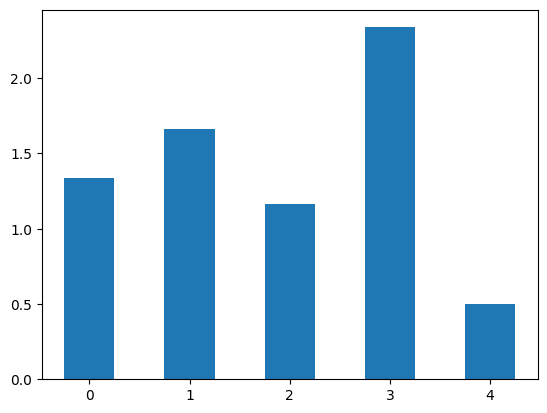

In [94]:
import matplotlib.pyplot as plt
plt.bar(np.arange(5), np.sum(document_topics, axis=0), width=0.5)

# Exercise

## string replacement

In [ ]:
# for reference
# in Pandas dataframes, it support regular expressions in the first argument.
# But, in regular Python strings, str.replace() method does not directly support regular expressions in its first argument.
# - you will have to use re.sub()

x = "aa kk3abb bc'cc cdddd"
print(x.replace("[^a-zA-Z]", " "))

import re

x2 = re.sub(r'[^a-zA-Z]', ' ', x)
print(x2)

df = pd.DataFrame(columns=['a'])

df['a'] = [x]
df['a'] = df['a'].str.replace("[^a-zA-Z]", " ", regex=True)  # default: True will change to False in the futue version.
df


## corpora.dictionary:
- it implements the concept of a Dictionary – a mapping between words and their integer ids.

In [ ]:
from gensim.corpora import Dictionary

texts = [['human', 'interface', 'computer', 'play'],
         ['men', 'data', 'science']]
dct = Dictionary(texts)  # initialize a Dictionary

In [ ]:
dct.token2id    # token -> token_id

In [ ]:
dct.add_documents([["cat", "say", "meow"],
                   ["dog", "say", "walwal"],
                   ['rabbit']])  # add more document (extend the vocabulary)
dct.token2id

In [ ]:
len(dct)

In [ ]:
# convert document into BoW format(id, counts)
dct.doc2bow(["dog", "play", "computer", "computer", "any_non_existent_word"])

## some python gramma exercises

In [ ]:
try:
    for i in range(5,-1,-1):
        print (5 // i)
except ZeroDivisionError:
    print("divide-by-zero error.")
finally:
    print("Done...")

In [ ]:
list(range(10,-1,-1))

In [ ]:
("{}").format(list(range(5)))

In [ ]:
("{}").format(*range(5))   # unpaking 을 했지만 녛을 자리가 한 개

In [ ]:
("{}--{}").format(*range(5))

In [ ]:
("{}" * 5).format(*range(5))

In [ ]:
("{:<5}" * 5).format(*range(5))

In [ ]:
a = [1,2,3]
print(a)
print(*a)

In [ ]:
d = {"A":12, "B": 56}
print(d)
print(*d)

- (Example) [Wikipedia] this distribution can be used if one wanted to cut strings (each of initial length 1.0) into K pieces with different lengths, where each piece had a designated average length (on average), but allowing some variation in the relative sizes of the pieces.
- Let's draw some samples from Dirichlet distribution based on some belief.
- **alpha**: Higher alpha values concentrate the distribution more around the mean, while lower alpha values result in a more spread-out distribution

- np.random.dirichlet(): 0~1 사이의 값을 가지며 이 요소들의 합은 1 이다.

In [ ]:
np.random.dirichlet((0.1, 0.1, 0.1), 10).round(2)   # 한 쪽으로 몰리는 경향

In [ ]:
np.random.dirichlet((10, 10, 10), 10).round(2)     # 모두를 포함하는 경향

In [ ]:
np.random.dirichlet((10, 0.1, 0.1), 10).round(2)

In [ ]:
np.random.dirichlet((1000, 1000, 1000), 10).round(2)

- nice Visualization of the Drichlet Distribution
  - https://blog.bogatron.net/blog/2014/02/02/visualizing-dirichlet-distributions/

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

corners = np.array([[0, 0], [1, 0], [0.5, 0.75**0.5]])
AREA = 0.5 * 1 * 0.75**0.5
triangle = tri.Triangulation(corners[:, 0], corners[:, 1])

In [ ]:
refiner = tri.UniformTriRefiner(triangle)
trimesh = refiner.refine_triangulation(subdiv=4)

plt.figure(figsize=(8, 4))
for (i, mesh) in enumerate((triangle, trimesh)):
    plt.subplot(1, 2, i+ 1)
    plt.triplot(mesh)
    plt.axis('off')
    plt.axis('equal')

In [ ]:
# For each corner of the triangle, the pair of other corners
pairs = [corners[np.roll(range(3), -i)[1:]] for i in range(3)]
# The area of the triangle formed by point xy and another pair or points
tri_area = lambda xy, pair: 0.5 * np.linalg.norm(np.cross(*(pair - xy)))

def xy2bc(xy, tol=1.e-4):
    '''Converts 2D Cartesian coordinates to barycentric.'''
    coords = np.array([tri_area(xy, p) for p in pairs]) / AREA
    return np.clip(coords, tol, 1.0 - tol)

In [ ]:
class Dirichlet(object):
    def __init__(self, alpha):
        from math import gamma
        from operator import mul
        self._alpha = np.array(alpha)
        self._coef = gamma(np.sum(self._alpha)) / \
                           np.multiply.reduce([gamma(a) for a in self._alpha])
    def pdf(self, x):
        '''Returns pdf value for `x`.'''
        from operator import mul
        return self._coef * np.multiply.reduce([xx ** (aa - 1)
                                               for (xx, aa)in zip(x, self._alpha)])

In [ ]:
def draw_pdf_contours(dist, nlevels=200, subdiv=8, **kwargs):
    import math

    refiner = tri.UniformTriRefiner(triangle)
    trimesh = refiner.refine_triangulation(subdiv=subdiv)
    pvals = [dist.pdf(xy2bc(xy)) for xy in zip(trimesh.x, trimesh.y)]

    plt.tricontourf(trimesh, pvals, nlevels, cmap='jet', **kwargs)
    plt.axis('equal')
    plt.xlim(0, 1)
    plt.ylim(0, 0.75**0.5)
    plt.axis('off')

In [ ]:
draw_pdf_contours(Dirichlet([1, 1, 1]))

In [ ]:
draw_pdf_contours(Dirichlet([0.999, 0.999, 0.999]))

In [ ]:
draw_pdf_contours(Dirichlet([5, 5, 5]))

In [ ]:
draw_pdf_contours(Dirichlet([50, 50, 50]))

In [ ]:
draw_pdf_contours(Dirichlet([6, 3, 1]))

In [ ]:
draw_pdf_contours(Dirichlet([10, 1, 1]))

# Simple example for LDA
- sklearn
- gensim
- example: generated using GPT

In [ ]:
# sklearn library

from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# Sample data
documents = [
    "I love programming and machine learning.",
    "Python and R are popular programming languages.",
    "Data science includes statistics and programming.",
    "Machine learning can be applied to various fields.",
    "Statistics is a fundamental aspect of data science."
]

# Preprocess the documents (convert to count vectors)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)

# Parameters
n_topics = 3
alpha = 0.1  # doc_topic_prior
beta = 0.01  # topic_word_prior
n_iterations = 100  # Number of iterations

# Create the LDA model
lda = LatentDirichletAllocation(n_components=n_topics,
                                doc_topic_prior=alpha,
                                topic_word_prior=beta,
                                max_iter=n_iterations,
                                random_state=0)
lda.fit(X)

# Get the topic-word matrix
topic_word_matrix = lda.components_

# Normalize the topic-word matrix to get the probability distribution
topic_word_prob = topic_word_matrix / topic_word_matrix.sum(axis=1)[:, np.newaxis]

# Display normalized topics
# Print the most probable 10 words for each topic.

terms = vectorizer.get_feature_names_out()
for index, topic in enumerate(topic_word_prob):
    print(f"Topic {index + 1}:")
    print(" ".join([terms[i] for i in topic.argsort()[:-11:-1]]))

In [ ]:
topic_word_prob[0].argsort()[:-11:-1]

In [ ]:
a = np.array([1,2])
a[:].shape, a[:,np.newaxis].shape

In [ ]:
# gensim library

from gensim import corpora
from gensim.models.ldamodel import LdaModel

# Preprocess the documents (convert to bag-of-words format)
texts = [doc.lower().split() for doc in documents]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
n_iterations =    1000  # Number of iterations

# Parameters
n_topics = 3
alpha = [0.1] * n_topics  # Can also be a single scalar value
beta = 0.01               # Can also be a list of values for each word

# Create the LDA model
lda = LdaModel(corpus=corpus,
               num_topics=n_topics,
               id2word=dictionary,
               alpha=alpha,
               eta=beta,
               iterations=n_iterations,
               random_state=0)

# Extract the topic-word distributions
topic_word_prob = lda.get_topics()

# Display normalized topics
for i, topic in enumerate(topic_word_prob):
    print(f"Topic {i + 1}:")
    print(" ".join([dictionary.get(id) for id in topic.argsort()[:-11:-1]]))

--------------------------